In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

In [7]:
def plot_hosts(file_path):

    file_to_read = f"{file_path}/execute_stat_80.csv"
    
    try:
        df = pd.read_csv(file_to_read)
    except FileNotFoundError:
        print(f"Ошибка: Файл не найден. Убедитесь, что {file_to_read} существует.")
        return

    if df.empty:
        print("Нет данных для анализа и построения графика.")
        return

    df['group'] = df['client'].str[1]
    df['interval'] = df['end'] - df['start']

    time_by_type = (
        df.groupby(['client', 'group', 'type'])['interval']
        .sum()
        .unstack(level='type', fill_value=0)
        .reset_index()
    )

    busy_columns = [col for col in time_by_type.columns if col.startswith('busy:')]
    time_by_type['busy_time'] = time_by_type[busy_columns].sum(axis=1)
    time_by_type['idle_time'] = time_by_type.get('idle:', 0)
    time_by_type['unavailable_time'] = time_by_type.get('unavailable:', 0)

    time_by_type['total_time'] = time_by_type['busy_time'] + time_by_type['idle_time'] + time_by_type['unavailable_time']
    time_by_type['active_time'] = time_by_type['total_time'] - time_by_type['unavailable_time']

    time_by_type['mean_util'] = (
        time_by_type['busy_time'] / time_by_type['active_time']
    ).fillna(0) * 100
    
    plt.figure(figsize=(10, 7))
    
    ax = sns.barplot(data=time_by_type, x='group', y='mean_util', palette='viridis', errorbar=None)
    
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1f}%", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points')

    plt.xlabel("Группа хостов")
    plt.ylabel("Средняя утилизация за время активности (%)")
    plt.title("Средняя утилизация хостов по группам (относительно времени активности)")
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


In [8]:
def boxplot_host_utilization(ax, file_path, group_size, replication):
    try:
        df = pd.read_csv(file_path)
        df['timestamp'] = (df['timestamp'] / 3600).round()
        df_long = df.melt(id_vars=['timestamp'], var_name='host', value_name='utilization')
        sns.boxplot(x='timestamp', y='utilization', data=df_long, ax=ax)
        ax.set_title(f'Утилизация хостов (group_size={group_size}, replication={replication})')
        ax.set_xlabel('Временная метка (час)')
        ax.set_ylabel('Утилизация (%)')
        ax.tick_params(axis='x', rotation=45)
    except Exception as e:
        print(f"Ошибка при обработке {file_path}: {e}")

In [11]:
STAT_PATH = "C:/Users/xmelo/AppData/LocalLow/DefaultCompany/_monobeh_boinc/"
WORKUNITS_NAME = "host_utilization.csv"
PARAMS_NAME = "parameters.json"
exp_name = "statistics"

found ['statistics_9']


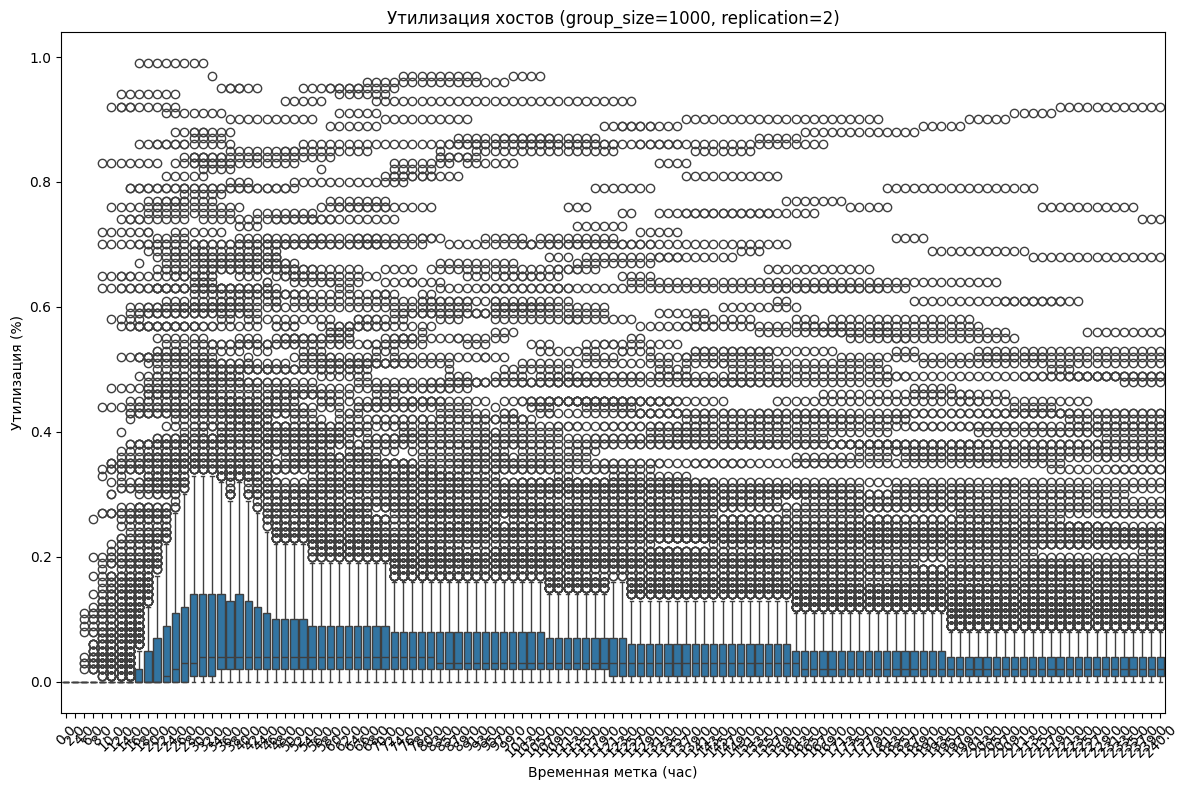

In [12]:


folders = [f for f in os.listdir(STAT_PATH) 
           if os.path.isdir(os.path.join(STAT_PATH,f)) and f.startswith(exp_name)]

if not folders:
    print(f"there is no folders in {STAT_PATH}")
else:
    print(f"found {folders}")

params_data = dict()
hosts_paths = dict()

for ind, exp_folder in enumerate(folders):
    full_path = os.path.join(STAT_PATH, exp_folder)
    parameters_path = os.path.join(full_path, PARAMS_NAME)
    
    with open(parameters_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        params_data[ind] = data
    
    hosts_paths[ind] = os.path.join(full_path, WORKUNITS_NAME)

num_plots = len(hosts_paths)
if num_plots > 0:
    fig, axes = plt.subplots(num_plots, 1, figsize=(12, 8 * num_plots), squeeze=False)
    axes = axes.flatten()
else:
    fig, axes = None, []

for i, (ind, path) in enumerate(hosts_paths.items()):
    ax = axes[i]
    group_size = params_data[ind]["GroupConfig"]["NumberOfClients"]
    replication_value = params_data[ind]["ProjectConfig"]["TaskConfig"]["InitialCreatedWorkunits"]
    boxplot_host_utilization(ax, path, group_size=group_size, replication=replication_value)

if num_plots > 0:
    plt.tight_layout()
    plt.show()
